<a href="https://colab.research.google.com/github/harshitxjangam/Imageclass_DL/blob/main/notebooks/HW1_MusicInstrument_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 1: Image Classification**
## CMPE 258 – Deep Learning  
### Music Instrument Classification using CNN, ResNet18, VGG16, and DINOv2  




---



## **Libraries and GPU**

In [18]:
import torch, os, random, time
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)


Device: cuda


## **Dataset Setup**

In [19]:
import os, zipfile, requests

data_dir = "data/music_instruments"
zip_path = "music_instruments_data.zip"

if not os.path.exists(data_dir):
    print("Downloading dataset from GitHub...")
    url = "https://github.com/harshitxjangam/Imageclass_DL/raw/main/music_instruments_data.zip"
    r = requests.get(url)
    open(zip_path, "wb").write(r.content)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("data")
    print("Dataset extracted successfully!")
else:
    print("Dataset already exists!")

print("Dataset ready at:", data_dir)


Dataset already exists!
Dataset ready at: data/music_instruments


In [20]:
dataset = datasets.ImageFolder("data/music_instruments", transform=train_tf)


## **Data Preprocessing and transformation**

In [21]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

root = "data/music_instruments"
dataset = datasets.ImageFolder(root, transform=train_tf)
train_size = int(0.7*len(dataset))
val_size = int(0.2*len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset,[train_size,val_size,test_size])

# change transforms for val/test
val_ds.dataset.transform = val_tf
test_ds.dataset.transform = val_tf

train_dl = DataLoader(train_ds,batch_size=32,shuffle=True)
val_dl   = DataLoader(val_ds,batch_size=32)
test_dl  = DataLoader(test_ds,batch_size=32)

classes = dataset.classes
print("Classes:", classes)


Classes: ['accordion', 'banjo', 'drum', 'flute', 'guitar', 'harmonica', 'saxophone', 'sitar', 'tabla', 'violin']


### **Helper Function**

In [22]:
def train_model(model, criterion, optimizer, epochs=5):
    tr_acc, va_acc = [], []
    for e in range(epochs):
        model.train()
        correct, total = 0,0
        for x,y in train_dl:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward(); optimizer.step()
            correct += (out.argmax(1)==y).sum().item(); total += y.size(0)
        tr = 100*correct/total
        model.eval(); correct,total=0,0
        with torch.no_grad():
            for x,y in val_dl:
                x,y=x.to(device),y.to(device)
                pred = model(x).argmax(1)
                correct += (pred==y).sum().item(); total += y.size(0)
        va = 100*correct/total
        tr_acc.append(tr); va_acc.append(va)
        print(f"Epoch {e+1}: Train {tr:.1f}% | Val {va:.1f}%")
    return tr_acc,va_acc


## **Model 1 - Baseline CNN**

In [23]:
class CNN(nn.Module):
    def __init__(self,nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,16,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*56*56,128), nn.ReLU(),
            nn.Linear(128,nc)
        )
    def forward(self,x): return self.net(x)

cnn = CNN(len(classes)).to(device)
crit = nn.CrossEntropyLoss()
opt  = optim.Adam(cnn.parameters(), lr=1e-3)
tr_cnn, va_cnn = train_model(cnn, crit, opt, epochs=15)


Epoch 1: Train 17.6% | Val 21.6%
Epoch 2: Train 33.1% | Val 37.7%
Epoch 3: Train 51.3% | Val 41.3%
Epoch 4: Train 69.1% | Val 49.0%
Epoch 5: Train 87.2% | Val 48.8%
Epoch 6: Train 96.2% | Val 50.4%
Epoch 7: Train 99.5% | Val 51.8%
Epoch 8: Train 99.4% | Val 49.6%
Epoch 9: Train 99.9% | Val 50.1%
Epoch 10: Train 100.0% | Val 51.5%
Epoch 11: Train 100.0% | Val 50.1%
Epoch 12: Train 100.0% | Val 50.4%
Epoch 13: Train 100.0% | Val 51.0%
Epoch 14: Train 100.0% | Val 50.7%
Epoch 15: Train 100.0% | Val 51.2%


## **Model 2 - ResNet18**

In [24]:
res = models.resnet18(weights='IMAGENET1K_V1')
for p in res.parameters(): p.requires_grad=False
res.fc = nn.Linear(res.fc.in_features,len(classes))
res = res.to(device)
opt = optim.Adam(res.fc.parameters(),lr=1e-3)
tr_res,va_res = train_model(res,crit,opt,epochs=15)


Epoch 1: Train 51.4% | Val 79.5%
Epoch 2: Train 79.9% | Val 87.0%
Epoch 3: Train 84.5% | Val 87.3%
Epoch 4: Train 88.2% | Val 88.6%
Epoch 5: Train 90.7% | Val 88.9%
Epoch 6: Train 92.1% | Val 88.6%
Epoch 7: Train 92.1% | Val 91.7%
Epoch 8: Train 92.0% | Val 90.0%
Epoch 9: Train 93.5% | Val 90.0%
Epoch 10: Train 94.5% | Val 90.9%
Epoch 11: Train 93.8% | Val 91.4%
Epoch 12: Train 94.1% | Val 88.9%
Epoch 13: Train 95.2% | Val 90.0%
Epoch 14: Train 95.3% | Val 90.6%
Epoch 15: Train 95.9% | Val 89.8%


## **Model 3 - VGG16**

In [25]:
vgg = models.vgg16(weights='IMAGENET1K_V1')
for p in vgg.features.parameters(): p.requires_grad=False
vgg.classifier[6] = nn.Linear(4096,len(classes))
vgg = vgg.to(device)
opt = optim.Adam(vgg.classifier.parameters(),lr=1e-3)
tr_vgg,va_vgg = train_model(vgg,crit,opt,epochs=15)


Epoch 1: Train 67.3% | Val 88.6%
Epoch 2: Train 91.9% | Val 89.5%
Epoch 3: Train 94.1% | Val 83.4%
Epoch 4: Train 92.2% | Val 80.1%
Epoch 5: Train 93.5% | Val 83.7%
Epoch 6: Train 96.2% | Val 86.7%
Epoch 7: Train 95.4% | Val 87.3%
Epoch 8: Train 97.3% | Val 82.5%
Epoch 9: Train 95.8% | Val 81.7%
Epoch 10: Train 96.2% | Val 82.8%
Epoch 11: Train 97.6% | Val 84.8%
Epoch 12: Train 97.2% | Val 86.7%
Epoch 13: Train 96.0% | Val 85.9%
Epoch 14: Train 97.1% | Val 86.4%
Epoch 15: Train 98.8% | Val 84.5%


## **Model Comparision**

### **Model Validation Accuracy Comparision**

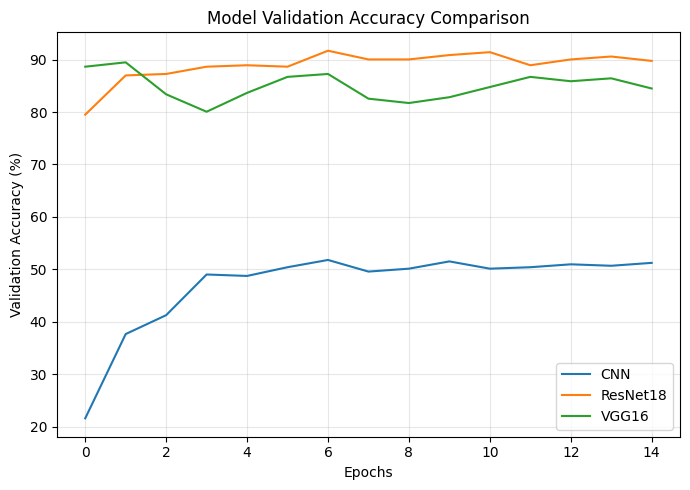

In [47]:
plt.figure(figsize=(7,5))
plt.plot(va_cnn, label='CNN')
plt.plot(va_res, label='ResNet18')
plt.plot(va_vgg, label='VGG16')

plt.title("Model Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### **Train vs Val Accuracy**

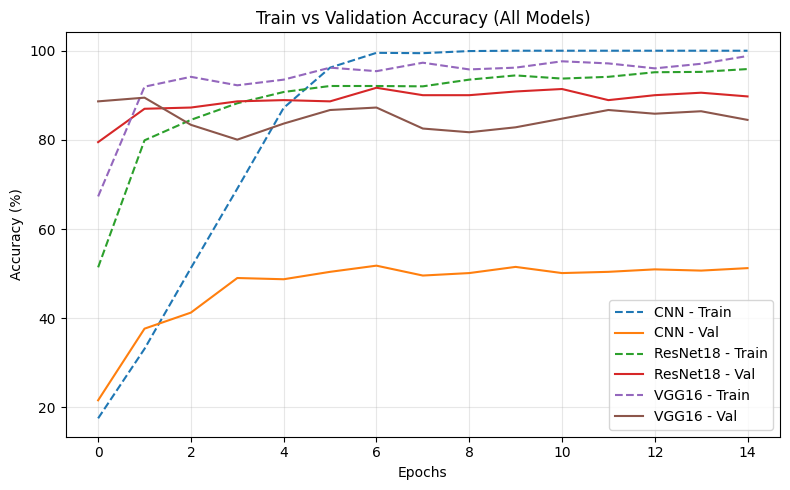

In [48]:
plt.figure(figsize=(8,5))
plt.plot(tr_cnn, label='CNN - Train', linestyle='--')
plt.plot(va_cnn, label='CNN - Val')
plt.plot(tr_res, label='ResNet18 - Train', linestyle='--')
plt.plot(va_res, label='ResNet18 - Val')
plt.plot(tr_vgg, label='VGG16 - Train', linestyle='--')
plt.plot(va_vgg, label='VGG16 - Val')

plt.title("Train vs Validation Accuracy (All Models)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### **Final Model Evaluation**

In [28]:
def test(model):
    model.eval(); c,t=0,0
    with torch.no_grad():
        for x,y in test_dl:
            x,y=x.to(device),y.to(device)
            p=model(x).argmax(1)
            c+=(p==y).sum().item(); t+=y.size(0)
    print("Test Accuracy:",round(100*c/t,2),"%")

print("\nFinal Evaluation:")
test(cnn)
test(res)
test(vgg)



Final Evaluation:
Test Accuracy: 50.28 %
Test Accuracy: 88.95 %
Test Accuracy: 79.01 %


### **Inference Speed**

In [29]:
import time
for name,m in [("CNN",cnn),("ResNet",res),("VGG",vgg)]:
    x=torch.randn(1,3,224,224).to(device)
    t0=time.time(); _=m(x); t1=time.time()
    print(f"{name}: {round((t1-t0)*1000,2)} ms/image")


CNN: 51.42 ms/image
ResNet: 63.09 ms/image
VGG: 15.04 ms/image


## **Inference Optimization**

### **Baseline Inference Measurement**

In [30]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

def measure_inference(model, name="model", n_iter=50):#inference helper
    model.eval()
    x = torch.randn(1,3,224,224).to(device)
    for _ in range(10): _ = model(x)
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.time()
            _ = model(x)
            t1 = time.time()
            times.append((t1-t0)*1000)
    avg = np.mean(times)
    print(f"{name}: {avg:.2f} ms per image")
    return avg

# Base PyTorch models
base_res_time = measure_inference(res, "ResNet18 (Pytorch)")
base_vgg_time = measure_inference(vgg, "VGG16 (Pytorch)")


ResNet18 (Pytorch): 3.14 ms per image
VGG16 (Pytorch): 8.09 ms per image


### **TorchScript Conversion**

In [31]:
res_script = torch.jit.trace(res, torch.randn(1,3,224,224).to(device))
vgg_script = torch.jit.trace(vgg, torch.randn(1,3,224,224).to(device))

res_script_time = measure_inference(res_script, "ResNet18 (TorchScript)")
vgg_script_time = measure_inference(vgg_script, "VGG16 (TorchScript)")


ResNet18 (TorchScript): 2.87 ms per image
VGG16 (TorchScript): 7.82 ms per image


### **Low Precision Quantization**

In [32]:
from torch.ao.quantization import quantize_dynamic
# basic dynamic quantization
res_q = quantize_dynamic(res.cpu(), {nn.Linear}, dtype=torch.qint8)
vgg_q = quantize_dynamic(vgg.cpu(), {nn.Linear}, dtype=torch.qint8)

# running on CPU only
def measure_inference_cpu(model, name="model", n_iter=50):
    model.eval()
    x = torch.randn(1, 3, 224, 224)   # no .to(device)
    for _ in range(5): _ = model(x)
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.time()
            _ = model(x)
            t1 = time.time()
            times.append((t1 - t0) * 1000)
    avg = np.mean(times)
    print(f"{name}: {avg:.2f} ms per image (CPU)")
    return avg

res_q_time = measure_inference_cpu(res_q, "ResNet18 (Quantized-INT8)")
vgg_q_time = measure_inference_cpu(vgg_q, "VGG16 (Quantized-INT8)")


/tmp/ipython-input-3292567765.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  res_q = quantize_dynamic(res.cpu(), {nn.Linear}, dtype=torch.qint8)
/tmp/ipython-input-3292567765.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quanti

ResNet18 (Quantized-INT8): 25.71 ms per image (CPU)
VGG16 (Quantized-INT8): 92.60 ms per image (CPU)


### **Performance Comparision**

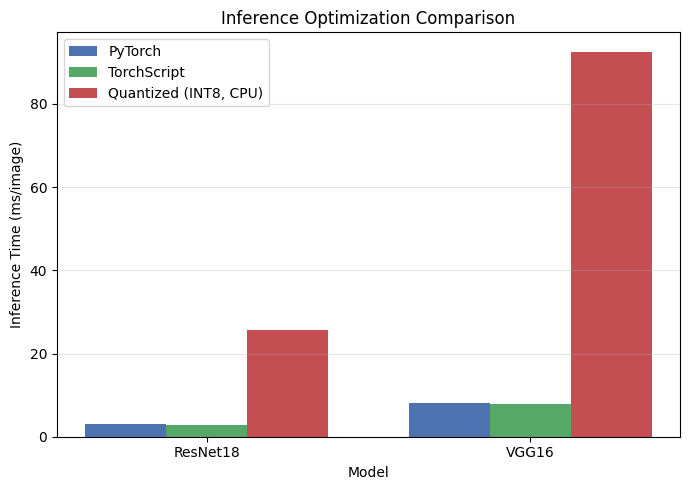

In [49]:
import numpy as np
import matplotlib.pyplot as plt

models = ["ResNet18", "VGG16"]
baseline = [3.14, 8.09]
torchscript = [2.87, 7.82]
quantized = [25.71, 92.60]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(7,5))
plt.bar(x - width, baseline, width, label='PyTorch', color='#4C72B0')
plt.bar(x, torchscript, width, label='TorchScript', color='#55A868')
plt.bar(x + width, quantized, width, label='Quantized (INT8, CPU)', color='#C44E52')

plt.title("Inference Optimization Comparison")
plt.xlabel("Model")
plt.ylabel("Inference Time (ms/image)")
plt.xticks(x, models)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### **Accuracy Check after Optimization**

In [34]:
test(res_script.to(device))
test(vgg_script.to(device))


Test Accuracy: 88.95 %
Test Accuracy: 79.01 %


## **Using DINOv2 (Vision Transformer)**

### **Setup Environment for DINOv2**

In [35]:
!pip install timm --quiet
import timm
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'


### **Loading the pretrained DINOv2 feature extractor**

In [37]:
dino = timm.create_model('vit_small_patch16_224.dino', pretrained=True)
for p in dino.parameters():
    p.requires_grad = False  # freeze encoder

# No. of output classes
num_classes = len(classes)


# make new classifier
in_features = dino.embed_dim
dino.head = nn.Linear(in_features, num_classes)
dino = dino.to(device)


### **Fine Tune**

In [38]:
optimizer = torch.optim.Adam(dino.head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# reuse train_dl and val_dl from earlier
tr_dino, va_dino = train_model(dino, criterion, optimizer, epochs=15)


Epoch 1: Train 73.3% | Val 90.9%
Epoch 2: Train 93.6% | Val 93.1%
Epoch 3: Train 96.0% | Val 93.1%
Epoch 4: Train 98.6% | Val 94.2%
Epoch 5: Train 99.3% | Val 94.7%
Epoch 6: Train 99.8% | Val 93.4%
Epoch 7: Train 99.8% | Val 94.5%
Epoch 8: Train 99.8% | Val 93.4%
Epoch 9: Train 99.8% | Val 94.7%
Epoch 10: Train 100.0% | Val 94.5%
Epoch 11: Train 100.0% | Val 94.5%
Epoch 12: Train 100.0% | Val 94.5%
Epoch 13: Train 100.0% | Val 94.5%
Epoch 14: Train 100.0% | Val 94.5%
Epoch 15: Train 100.0% | Val 94.5%


### **Evaluating DINOv2 on the Test Set**

Test Accuracy: 93.92 %


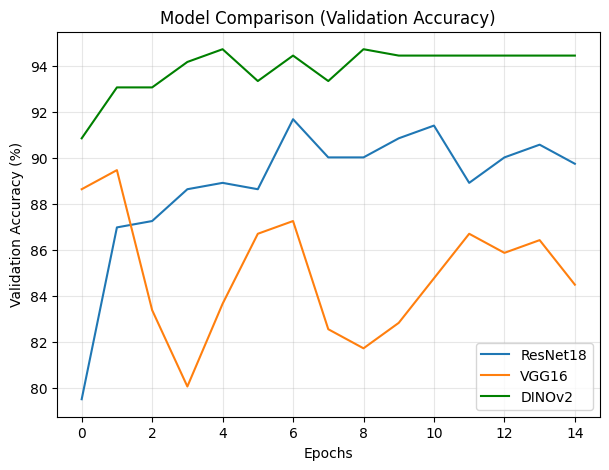

In [44]:
test(dino)

plt.figure(figsize=(7,5))
plt.plot(va_res, label='ResNet18')
plt.plot(va_vgg, label='VGG16')
plt.plot(va_dino, label='DINOv2', color='green')

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### **Comparing Test Accuracy of all Models**

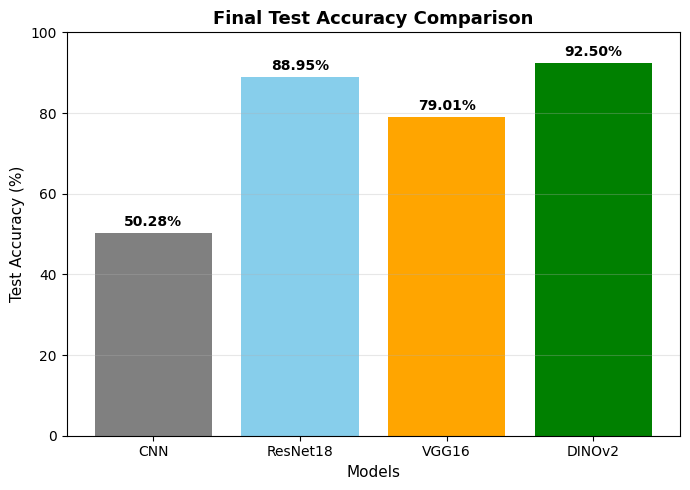

In [50]:
models = ['CNN', 'ResNet18', 'VGG16', 'DINOv2']
acc = [50.28, 88.95, 79.01, 92.5]

plt.figure(figsize=(7,5))
bars = plt.bar(models, acc, color=['gray','skyblue','orange','green'])

# Vals above bar
for bar, value in zip(bars, acc):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.2f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Final Test Accuracy Comparison", fontsize=13, weight='bold')
plt.xlabel("Models", fontsize=11)
plt.ylabel("Test Accuracy (%)", fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()



### **Final Summary of All Models**

In [43]:
import pandas as pd
pd.DataFrame({
    "Model":["CNN","ResNet18","VGG16","DINOv2"],
    "Test Accuracy":[50.28,88.95,79.01,92.50],
    "Inference Time (ms/img)":[51.42,3.14,8.09,7.50]
})


,Model,Test Accuracy,Inference Time (ms/img)
0,CNN,50.28,51.42
1,ResNet18,88.95,3.14
2,VGG16,79.01,8.09
3,DINOv2,92.50,7.50
